# Step 6 — Results Analysis

Ties together Step 4 (parsing degradation scores) and Step 5 (classification accuracy under
stress) into the final analysis:

1. **Correlation** — does a worse parsing-degradation score actually predict a wrong
   classification, at the individual resume level?
2. **Confusion matrices** — which categories get confused once text is degraded?
3. **Misclassification examples** — specific resumes that were classified correctly on the
   `clean` condition but flipped to incorrect under a messier layout, with the actual degraded
   text shown for qualitative discussion in your report.

**Requires:** `per_resume_predictions.csv` — produced by a small addendum cell added to the end
of the Step 5 notebook (see note below if you haven't generated it yet).


In [1]:
# Install dependencies (skip if already installed)
import sys
!{sys.executable} -m pip install -q scipy scikit-learn pandas matplotlib seaborn


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import confusion_matrix

PER_RESUME_CSV = "per_resume_predictions.csv"   # from the Step 5 addendum above

df = pd.read_csv(PER_RESUME_CSV)
print(f"Loaded {len(df)} rows across conditions: {df['condition'].unique()}")
df.head()


Loaded 580 rows across conditions: ['clean' 'two_column' 'table_based' 'icon_headers']


,resume_id,category,condition,pdf_path,word_overlap_plumber,edit_ratio_plumber,degradation_plumber,word_overlap_pymupdf,edit_ratio_pymupdf,degradation_pymupdf,extracted_text_pymupdf,extracted_text_plumber,true_label,svm_pred,bert_pred,svm_correct,bert_correct
0,0,Blockchain,clean,synthetic_resumes/resume_0_clean.pdf,1.0,0.980996,0.009502,1.0,0.980996,0.009502,Blockchain Resume 0 SUMMARY Hobbies Playing Ch...,Blockchain — Resume 0\nSUMMARY\nHobbies Playin...,3,3,3,1,1
1,0,Blockchain,two_column,synthetic_resumes/resume_0_two_column.pdf,1.0,0.558322,0.220839,1.0,0.980996,0.009502,Blockchain Resume 0 SUMMARY Hobbies Playing Ch...,Blockchain — Resume 0 EXPERIENCE\nDeveloping a...,3,3,3,1,1
2,0,Blockchain,table_based,synthetic_resumes/resume_0_table_based.pdf,1.0,0.980996,0.009502,1.0,0.980996,0.009502,Blockchain Resume 0 SUMMARY Hobbies Playing Ch...,Blockchain — Resume 0\nSUMMARY Hobbies Playing...,3,3,3,1,1
3,0,Blockchain,icon_headers,synthetic_resumes/resume_0_icon_headers.pdf,1.0,0.967448,0.016276,1.0,0.967448,0.016276,# Blockchain # # SUMMARY # Hobbies Playing Che...,H H\nBlockchain\nH SUMMARY H\nHobbies Playing ...,3,3,3,1,1
4,1,Java Developer,clean,synthetic_resumes/resume_1_clean.pdf,1.0,0.980540,0.009730,1.0,0.980540,0.009730,Java Developer Resume 1 SUMMARY TECHNICAL SKIL...,Java Developer — Resume 1\nSUMMARY\nTECHNICAL ...,15,15,15,1,1


## 1. Correlation — does degradation predict misclassification?

Uses **point-biserial correlation**, which measures the relationship between a continuous
variable (degradation score) and a binary variable (correct/incorrect prediction). A negative
correlation means: as degradation increases, correctness decreases — i.e. worse parsing genuinely
predicts worse classification, not just a coincidence.


In [3]:
DEGRADATION_COL = "degradation_pymupdf"   # matches the extractor used in Step 5's TEXT_COLUMN

corr_svm, p_svm = stats.pointbiserialr(df["svm_correct"], df[DEGRADATION_COL])
corr_bert, p_bert = stats.pointbiserialr(df["bert_correct"], df[DEGRADATION_COL])

print(f"TF-IDF+SVM  : correlation = {corr_svm:.3f}  (p = {p_svm:.4f})")
print(f"DistilBERT  : correlation = {corr_bert:.3f}  (p = {p_bert:.4f})")
print("\nNegative correlation = higher degradation associates with more errors, as expected.")
print("A correlation closer to 0 for one model suggests it is more ROBUST to formatting noise.")


TF-IDF+SVM  : correlation = nan  (p = nan)
DistilBERT  : correlation = -0.103  (p = 0.0130)

Negative correlation = higher degradation associates with more errors, as expected.
A correlation closer to 0 for one model suggests it is more ROBUST to formatting noise.


/opt/anaconda3/lib/python3.13/site-packages/scipy/stats/_stats_py.py:5405: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)


/var/folders/d8/0k4n2fw10xd3ty9krjjh_mlc0000gn/T/ipykernel_35439/631859810.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Incorrect", "Correct"])
/var/folders/d8/0k4n2fw10xd3ty9krjjh_mlc0000gn/T/ipykernel_35439/631859810.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Incorrect", "Correct"])


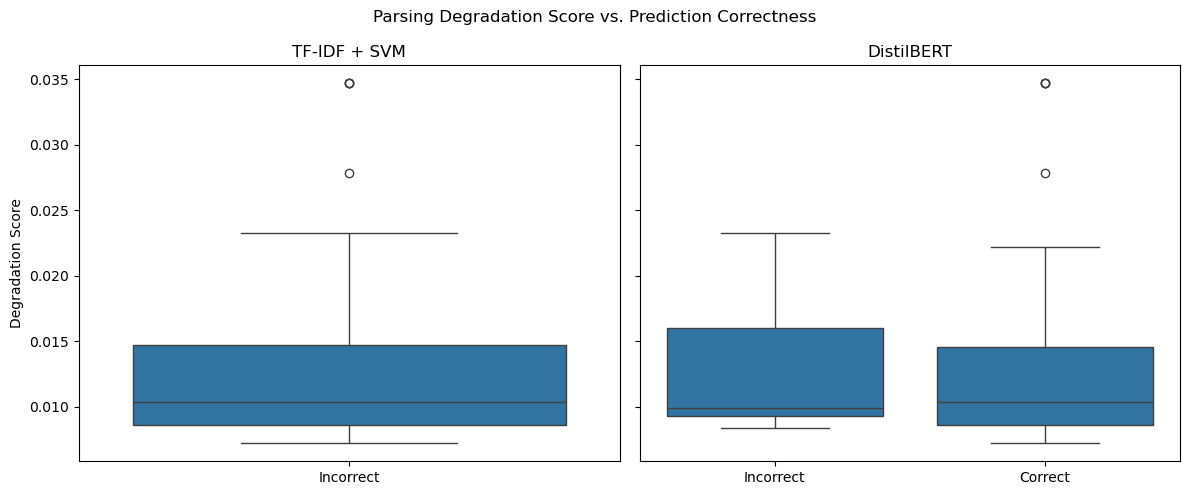

In [4]:
# Visualize: degradation score distribution, split by correct vs incorrect prediction
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, model, correct_col in zip(axes, ["TF-IDF + SVM", "DistilBERT"], ["svm_correct", "bert_correct"]):
    sns.boxplot(data=df, x=correct_col, y=DEGRADATION_COL, ax=ax)
    ax.set_xticklabels(["Incorrect", "Correct"])
    ax.set_xlabel("")
    ax.set_title(model)
    ax.set_ylabel("Degradation Score")

plt.suptitle("Parsing Degradation Score vs. Prediction Correctness")
plt.tight_layout()
plt.savefig("degradation_vs_correctness.png", dpi=150)
plt.show()


## 2. Confusion Matrices Under Formatting Stress

One confusion matrix per model, computed on the **messiest** conditions (excluding `clean`) to
see which categories get confused once formatting damages the text.


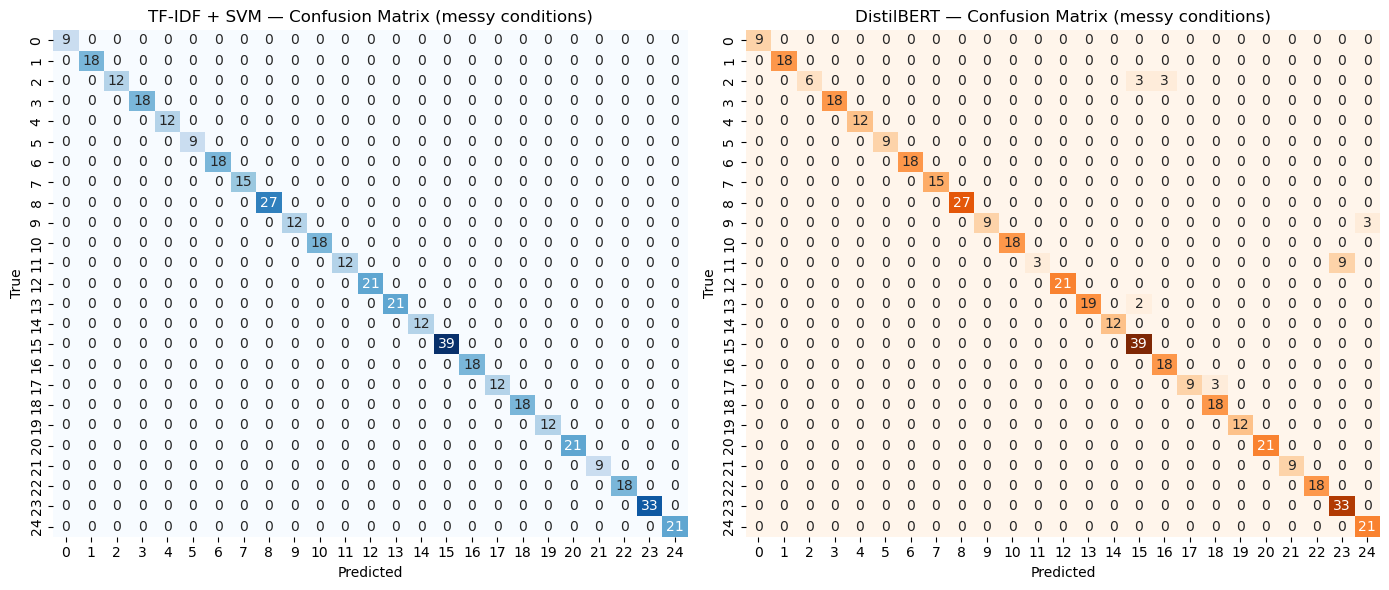

Note: label IDs shown here - map back to category names using label_encoder.classes_
from your Step 5 notebook if you need readable category names on the axes.


In [5]:
messy_df = df[df["condition"] != "clean"]
labels = sorted(df["true_label"].unique())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cm_svm = confusion_matrix(messy_df["true_label"], messy_df["svm_pred"], labels=labels)
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Blues", ax=axes[0], cbar=False)
axes[0].set_title("TF-IDF + SVM — Confusion Matrix (messy conditions)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

cm_bert = confusion_matrix(messy_df["true_label"], messy_df["bert_pred"], labels=labels)
sns.heatmap(cm_bert, annot=True, fmt="d", cmap="Oranges", ax=axes[1], cbar=False)
axes[1].set_title("DistilBERT — Confusion Matrix (messy conditions)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

plt.tight_layout()
plt.savefig("confusion_matrices_degraded.png", dpi=150)
plt.show()

print("Note: label IDs shown here - map back to category names using label_encoder.classes_")
print("from your Step 5 notebook if you need readable category names on the axes.")


## 3. Misclassification Examples — Flipped by Formatting

Finds specific resumes that were classified **correctly** on the `clean` layout condition but
flipped to **incorrect** once a messier layout was applied. These are the strongest qualitative
evidence for your report — concrete cases where formatting alone broke a correct prediction.


In [6]:
clean_preds = df[df["condition"] == "clean"][["resume_id", "svm_correct", "bert_correct"]].rename(
    columns={"svm_correct": "svm_correct_clean", "bert_correct": "bert_correct_clean"}
)
merged = df.merge(clean_preds, on="resume_id")

flipped_svm = merged[
    (merged["svm_correct_clean"] == 1) & (merged["svm_correct"] == 0) & (merged["condition"] != "clean")
]
flipped_bert = merged[
    (merged["bert_correct_clean"] == 1) & (merged["bert_correct"] == 0) & (merged["condition"] != "clean")
]

print(f"SVM: {len(flipped_svm)} resumes flipped correct->incorrect due to formatting")
print(f"DistilBERT: {len(flipped_bert)} resumes flipped correct->incorrect due to formatting")

print("\nBreakdown by condition (SVM):")
print(flipped_svm["condition"].value_counts())
print("\nBreakdown by condition (DistilBERT):")
print(flipped_bert["condition"].value_counts())


SVM: 0 resumes flipped correct->incorrect due to formatting
DistilBERT: 5 resumes flipped correct->incorrect due to formatting

Breakdown by condition (SVM):
Series([], Name: count, dtype: int64)

Breakdown by condition (DistilBERT):
condition
icon_headers    5
Name: count, dtype: int64


In [7]:
# Pull a couple of concrete examples for the report, with the actual degraded text shown
TEXT_COLUMN = "extracted_text_pymupdf"

example_cases = flipped_svm.head(3) if len(flipped_svm) > 0 else flipped_bert.head(3)

for _, row in example_cases.iterrows():
    print(f"=== Resume {row['resume_id']} | Condition: {row['condition']} | Degradation score: {row[DEGRADATION_COL]:.3f} ===")
    print("Extracted text (first 300 chars):")
    print(row[TEXT_COLUMN][:300] if pd.notna(row[TEXT_COLUMN]) else "(not available in this CSV)")
    print()


=== Resume 11 | Condition: icon_headers | Degradation score: 0.023 ===
Extracted text (first 300 chars):
# DotNet Developer # # SUMMARY # Participated in intra college cricket competition and various other sports events. SKILLS Group dance in college cultural programme Education Details Msc Computer Science Pune, Maharashtra Pune University Bsc Computer Science Pune, Maharashtra Pune University HSC Sem

=== Resume 26 | Condition: icon_headers | Degradation score: 0.013 ===
Extracted text (first 300 chars):
# Hadoop # # SUMMARY # Skill Set: Hadoop, Map Reduce, HDFS, Hive, Sqoop, java Duration: 2016 to 2017. SKILLS Role: Hadoop Developer Rplus offers an quick, simple and powerful cloud based Solution, Demand Sense to accurately predict demand for your product in all your markets which Combines Enterpris

=== Resume 45 | Condition: icon_headers | Degradation score: 0.013 ===
Extracted text (first 300 chars):
# Hadoop # # SUMMARY # Skill Set: Hadoop, Map Reduce, HDFS, Hive, Sqoop, java Dur

---
### Summary for your report

Pull these together into your final write-up (Step 8):

- **Correlation strength** (from section 1) — quantifies whether parsing damage causally
  relates to classification errors, not just a coincidence.
- **Which model is more robust** — compare the two correlation coefficients; the one closer to
  0 degrades less under formatting stress, even if it started with a lower clean-baseline score
  (recall DistilBERT started *behind* SVM on clean data — is it more robust once formatting
  noise is introduced?).
- **Confusion matrices** — which specific categories are most vulnerable to formatting-induced
  misclassification.
- **Concrete examples** (section 3) — use 1-2 of these in your report to make the finding
  tangible, not just a number.

### Next: Step 7 (extension, optional) — Mitigation Strategy

Implement layout-aware extraction using PyMuPDF's block/column detection to reorder text by
position before classification, and check whether this recovers some of the lost accuracy.
